In [59]:
# Mount Google Drive in Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd # Python library used primarily for data manipulation, cleaning, exploration, and analysis
import matplotlib.pyplot as plt # Python library used for creating static, animated, and interactive visualizations in Python
import numpy as np # Python library used for working with arrays, linear algebra, and mathematical functions

In [61]:
path = "/content/drive/MyDrive/finance_3_months.csv"

df = pd.read_csv(path)
df.head()

,date,income,income_currency,expense,expense_currency,category
0,2026-05-01,0.0,RUB,1577.98,RUB,Housing
1,2026-05-02,0.0,RUB,2711.37,RUB,Food
2,2026-05-03,0.0,RUB,6183.10,RUB,Food
3,2026-05-04,0.0,RUB,1819.35,RUB,Other
4,2026-05-05,3000.0,RUB,1923.44,RUB,Housing


### Exploratory Data Analysis 
#### 1. Dataset Overview and Descriptive Statistics

In [62]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDataset info:")
df.info()

Dataset shape: (92, 6)

Columns:
['date', 'income', 'income_currency', 'expense', 'expense_currency', 'category']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              92 non-null     object 
 1   income            92 non-null     float64
 2   income_currency   92 non-null     object 
 3   expense           92 non-null     float64
 4   expense_currency  92 non-null     object 
 5   category          92 non-null     object 
dtypes: float64(2), object(4)
memory usage: 4.4+ KB


In [63]:
# Analyze the data types of each column in the DataFrame
df.dtypes

,0
date,object
income,float64
income_currency,object
expense,float64
expense_currency,object
category,object


In [64]:
# Period of the dataset
df["date"] = pd.to_datetime(df["date"])
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

print("Number of days:", df["date"].nunique())

Start date: 2026-05-01 00:00:00
End date: 2026-07-31 00:00:00
Number of days: 92


In [65]:
# Check if date changed its dtype
print(df.dtypes)

date                datetime64[ns]
income                     float64
income_currency             object
expense                    float64
expense_currency            object
category                    object
dtype: object


In [66]:
# Check for duplicated rows in DataFrame
duplicates = df[df.duplicated(keep=False)]

print("Number of duplicated rows:", duplicates.shape[0])

if not duplicates.empty:
    display(duplicates)

Number of duplicated rows: 0


In [67]:
# Check for missing values in the DataFrame
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

display(missing)

,missing_count,missing_percent
date,0,0.0
income,0,0.0
income_currency,0,0.0
expense,0,0.0
expense_currency,0,0.0
category,0,0.0


In [68]:
# Overview of the DataFrame, including count, mean, std, min, 25%, 50%, 75%, and max for each numeric column
df.describe()

,date,income,expense
count,92,92.000000,92.000000
mean,2026-06-15 12:00:00,3271.739130,1875.578152
min,2026-05-01 00:00:00,0.000000,35.260000
25%,2026-05-23 18:00:00,0.000000,1272.592500
50%,2026-06-15 12:00:00,0.000000,1591.430000
75%,2026-07-08 06:00:00,0.000000,2216.452500
max,2026-07-31 00:00:00,85000.000000,6203.990000
std,NaN,15243.159706,1139.962991


In [69]:
numeric_cols = ["income", "expense"]

display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
income,92.0,3271.739130,15243.159706,0.00,0.0000,0.00,0.0000,85000.00
expense,92.0,1875.578152,1139.962991,35.26,1272.5925,1591.43,2216.4525,6203.99


In [70]:
# Additional information on categorical features (income_currency, expense_currency, and category)
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("\n")

Column: income_currency
income_currency
RUB    92
Name: count, dtype: int64


Column: expense_currency
expense_currency
RUB    89
USD     3
Name: count, dtype: int64


Column: category
category
Food             36
Shopping         15
Transport        11
Entertainment     9
Housing           8
Other             8
Health            5
Name: count, dtype: int64




In [ ]:
# Check the distribution of income_currency, expense_currency, and category
print("Income currencies:")
print(df["income_currency"].value_counts())

print("\nExpense currencies:")
print(df["expense_currency"].value_counts())

print("\nCategories:")
print(df["category"].value_counts())

Income currencies:
income_currency
RUB    92
Name: count, dtype: int64

Expense currencies:
expense_currency
RUB    89
USD     3
Name: count, dtype: int64

Categories:
category
Food             36
Shopping         15
Transport        11
Entertainment     9
Housing           8
Other             8
Health            5
Name: count, dtype: int64


#### 2. Data Quality Assessment and Visualization

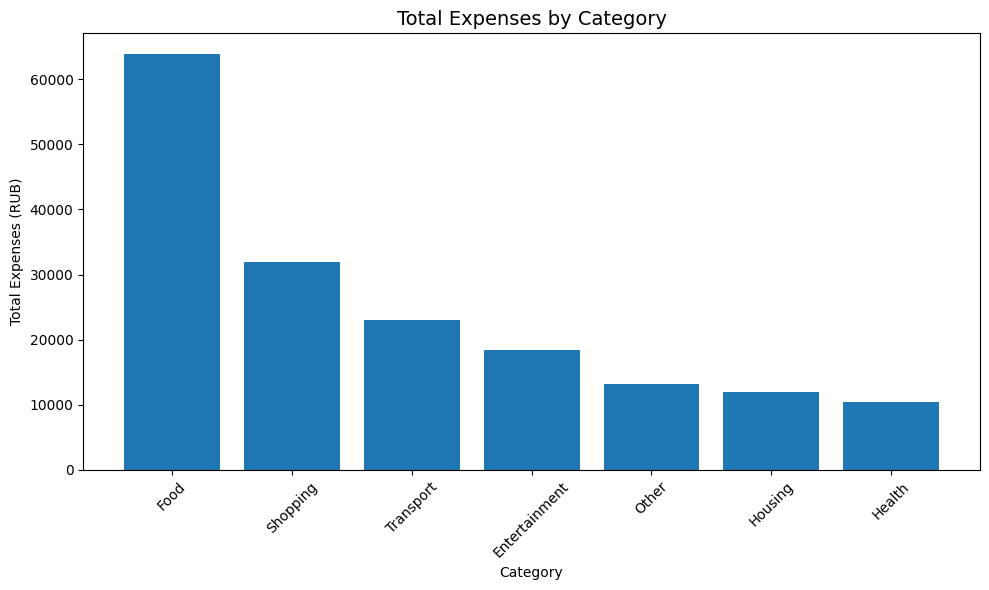

In [79]:
# Calculate the total expenses for each category
category_expenses = (
    df.groupby("category")["expense"]
      .sum()
      .sort_values(ascending=False)
)

# Visualize total expenses by category
plt.figure(figsize=(10, 6))

plt.bar(
    category_expenses.index,
    category_expenses.values
)

plt.title("Total Expenses by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Total Expenses (RUB)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

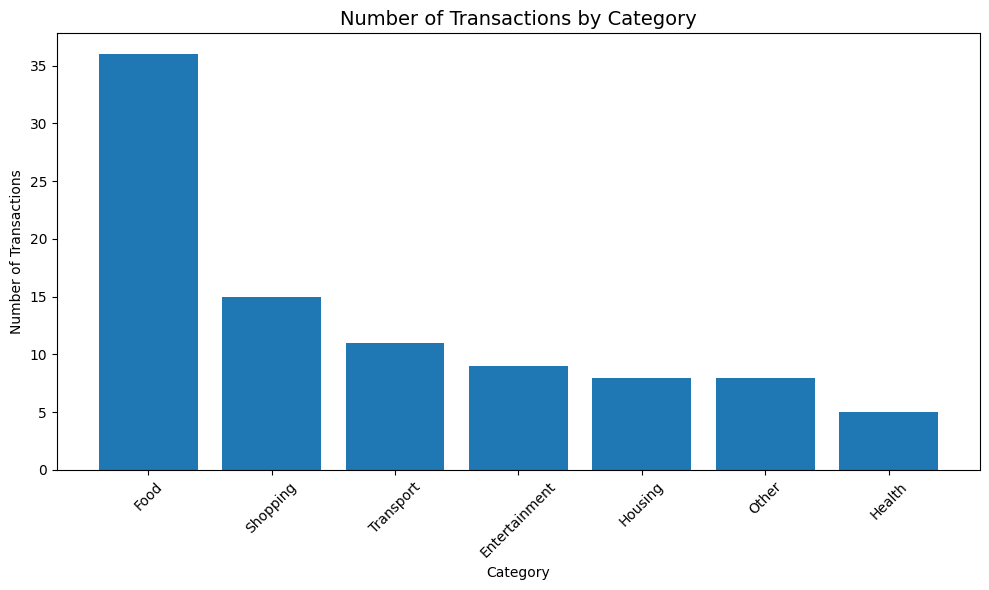

In [80]:
# Count the number of transactions in each category
category_counts = df["category"].value_counts()

# Visualize the number of transactions by category
plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title("Number of Transactions by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

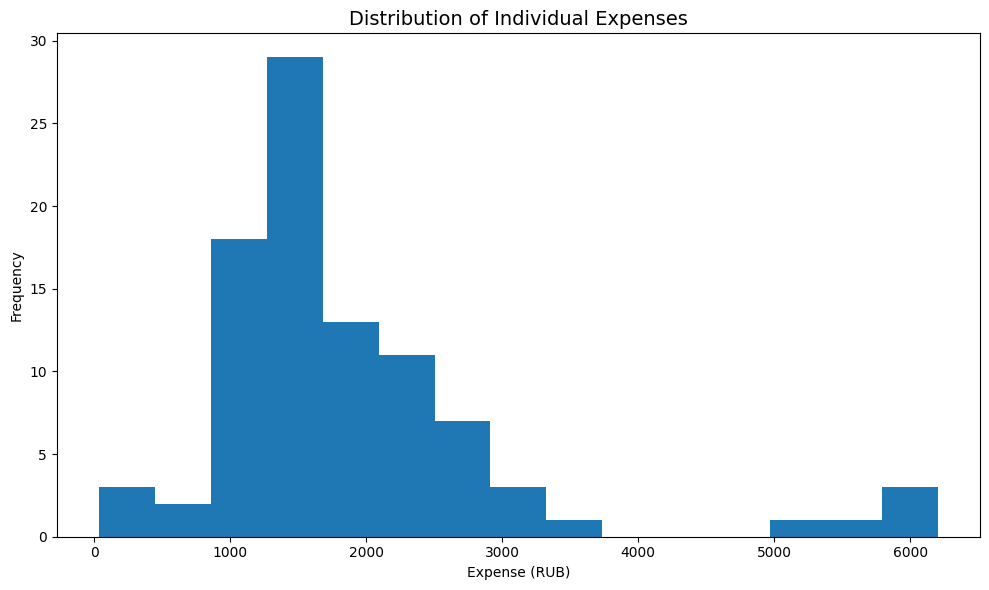

In [81]:
# Visualize the distribution of individual expenses
plt.figure(figsize=(10, 6))

plt.hist(
    df["expense"],
    bins=15
)

plt.title("Distribution of Individual Expenses", fontsize=14)
plt.xlabel("Expense (RUB)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

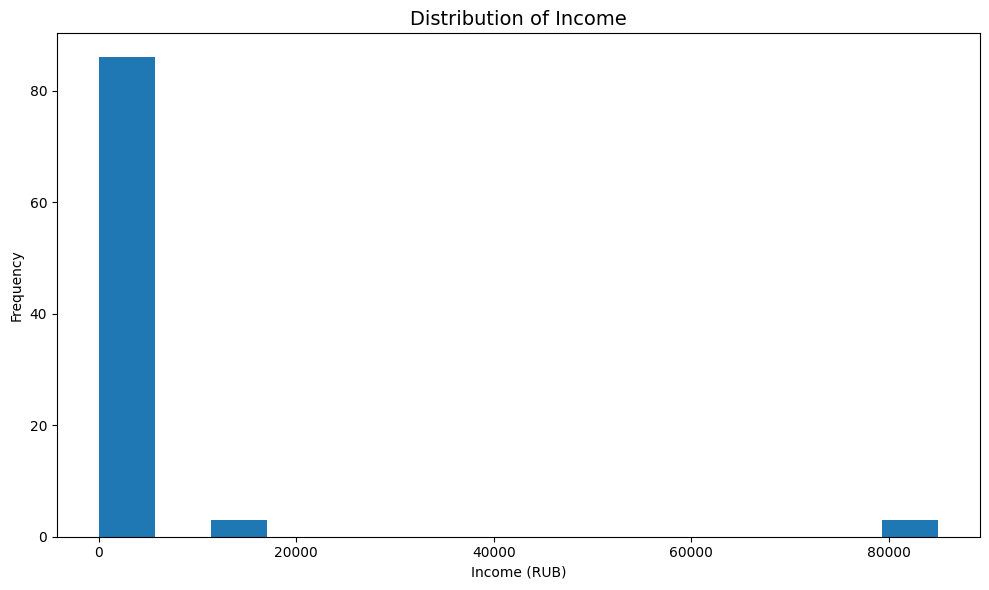

In [82]:
# Visualize the distribution of income values
plt.figure(figsize=(10, 6))

plt.hist(
    df["income"],
    bins=15
)

plt.title("Distribution of Income", fontsize=14)
plt.xlabel("Income (RUB)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

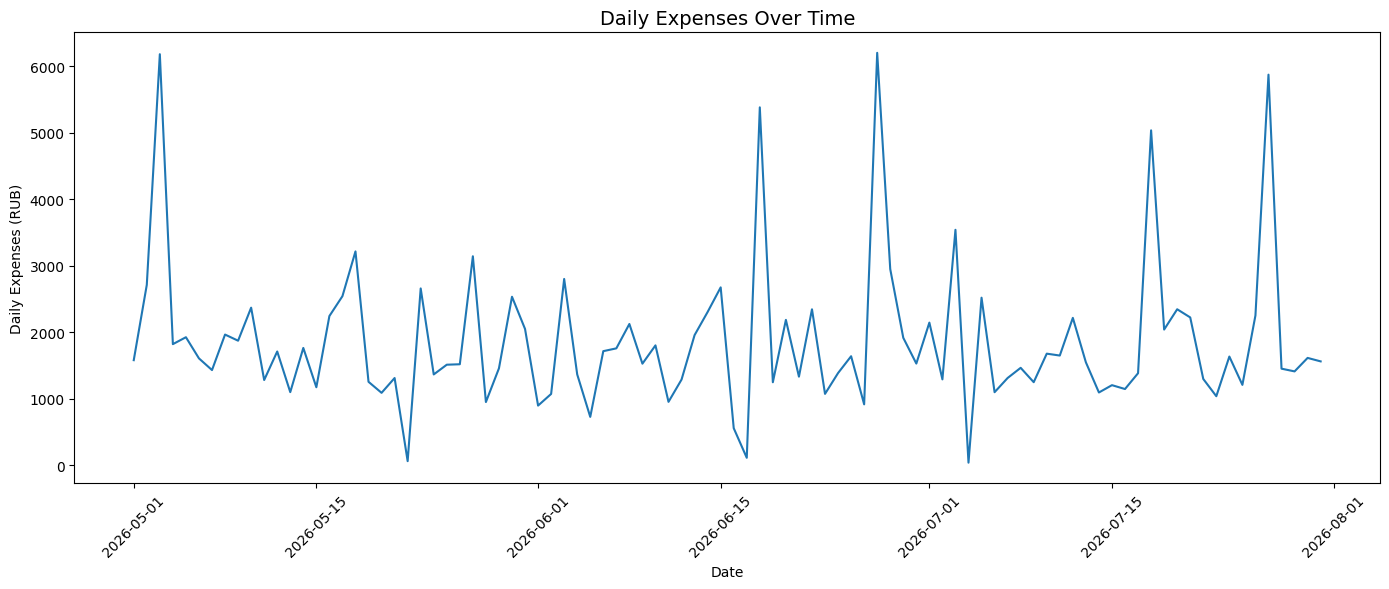

In [83]:
# Aggregate total expenses for each date
daily_expenses = (
    df.groupby("date")["expense"]
      .sum()
)

# Visualize daily expenses over time
plt.figure(figsize=(14, 6))

plt.plot(
    daily_expenses.index,
    daily_expenses.values
)

plt.title("Daily Expenses Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Daily Expenses (RUB)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

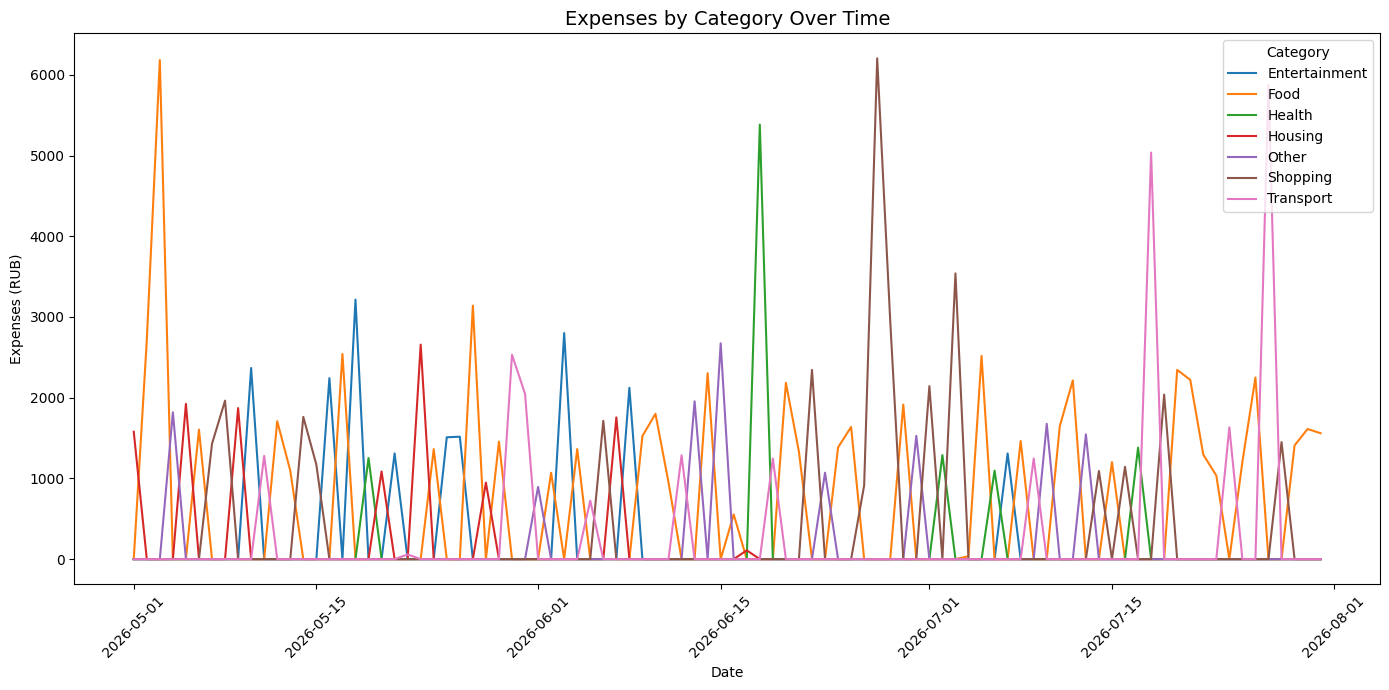

In [84]:
# Aggregate expenses by date and category
category_over_time = (
    df.groupby(["date", "category"])["expense"]
      .sum()
      .unstack(fill_value=0)
)

# Visualize expenses by category over time
plt.figure(figsize=(14, 7))

for category in category_over_time.columns:
    plt.plot(
        category_over_time.index,
        category_over_time[category],
        label=category
    )

plt.title("Expenses by Category Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Expenses (RUB)")

plt.xticks(rotation=45)
plt.legend(title="Category")

plt.tight_layout()
plt.show()

#### 3. Outlier and Anomaly Detection.

In [85]:
# Check for negative income values
negative_income = df[df["income"] < 0]

print(f"Number of negative income values: {len(negative_income)}")

if not negative_income.empty:
    display(negative_income)

Number of negative income values: 0


In [86]:
# Check for negative expense values
negative_expenses = df[df["expense"] < 0]

print(f"Number of negative expense values: {len(negative_expenses)}")

if not negative_expenses.empty:
    display(negative_expenses)

Number of negative expense values: 0


In [87]:
# Define a function to detect statistical outliers using the IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return outliers, lower_bound, upper_bound

In [88]:
# Detect potential outliers in income values
income_outliers, income_lower, income_upper = detect_outliers_iqr(
    df, "income"
)

print(f"Income lower bound: {income_lower:.2f}")
print(f"Income upper bound: {income_upper:.2f}")
print(f"Number of potential income outliers: {len(income_outliers)}")

display(income_outliers)

Income lower bound: 0.00
Income upper bound: 0.00
Number of potential income outliers: 11


,date,income,income_currency,expense,expense_currency,category
4,2026-05-05,3000.0,RUB,1923.44,RUB,Housing
9,2026-05-10,85000.0,RUB,2368.28,RUB,Entertainment
24,2026-05-25,12000.0,RUB,1509.82,RUB,Entertainment
40,2026-06-10,85000.0,RUB,1800.75,RUB,Food
45,2026-06-15,1500.0,RUB,2673.82,RUB,Other
50,2026-06-20,2500.0,RUB,2184.68,RUB,Food
55,2026-06-25,12000.0,RUB,1637.35,RUB,Food
65,2026-07-05,1500.0,RUB,2518.56,RUB,Food
70,2026-07-10,85000.0,RUB,1676.01,RUB,Other
80,2026-07-20,1500.0,RUB,2344.28,RUB,Food


In [89]:
# Detect potential outliers in expense values
expense_outliers, expense_lower, expense_upper = detect_outliers_iqr(
    df, "expense"
)

print(f"Expense lower bound: {expense_lower:.2f}")
print(f"Expense upper bound: {expense_upper:.2f}")
print(f"Number of potential expense outliers: {len(expense_outliers)}")

display(expense_outliers)

Expense lower bound: -143.20
Expense upper bound: 3632.24
Number of potential expense outliers: 5


,date,income,income_currency,expense,expense_currency,category
2,2026-05-03,0.0,RUB,6183.10,RUB,Food
48,2026-06-18,0.0,RUB,5383.37,RUB,Health
57,2026-06-27,0.0,RUB,6203.99,RUB,Shopping
78,2026-07-18,0.0,RUB,5037.18,RUB,Transport
87,2026-07-27,0.0,RUB,5875.34,RUB,Transport


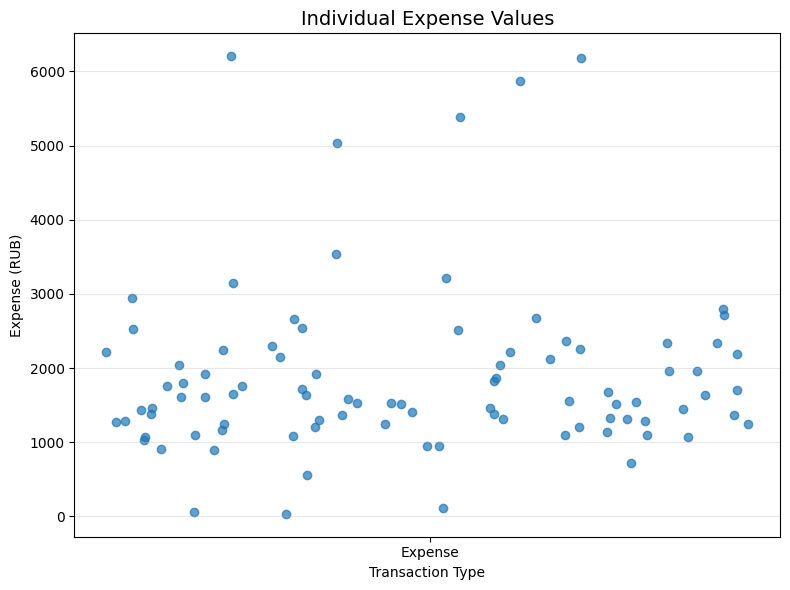

In [97]:
# Visualize individual expense values to identify potential outliers
np.random.seed(42)

# Create small horizontal offsets to reduce overlapping points
expense_x = 1 + np.random.uniform(-0.08, 0.08, len(df))

plt.figure(figsize=(8, 6))

plt.scatter(
    expense_x,
    df["expense"],
    alpha=0.7
)

plt.xticks(
    [1],
    ["Expense"]
)

plt.title("Individual Expense Values", fontsize=14)
plt.xlabel("Transaction Type")
plt.ylabel("Expense (RUB)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

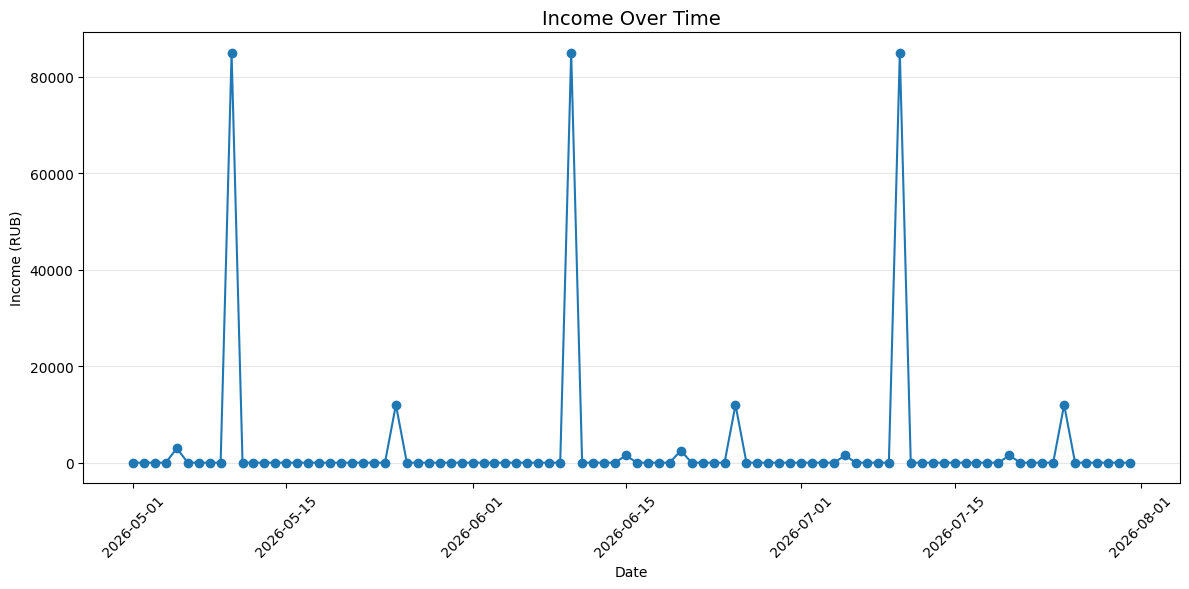

In [98]:
# Visualize income values over time to identify unusual financial events
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["income"],
    marker="o",
    linewidth=1.5
)

plt.title("Income Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Income (RUB)")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [99]:
# Identify the five largest income transactions
largest_income = df.nlargest(5, "income")

display(largest_income)

,date,income,income_currency,expense,expense_currency,category
9,2026-05-10,85000.0,RUB,2368.28,RUB,Entertainment
40,2026-06-10,85000.0,RUB,1800.75,RUB,Food
70,2026-07-10,85000.0,RUB,1676.01,RUB,Other
24,2026-05-25,12000.0,RUB,1509.82,RUB,Entertainment
55,2026-06-25,12000.0,RUB,1637.35,RUB,Food


In [102]:
# Identify the five largest expense transactions
largest_expenses = df.nlargest(5, "expense")

display(largest_expenses)

,date,income,income_currency,expense,expense_currency,category
57,2026-06-27,0.0,RUB,6203.99,RUB,Shopping
2,2026-05-03,0.0,RUB,6183.10,RUB,Food
87,2026-07-27,0.0,RUB,5875.34,RUB,Transport
48,2026-06-18,0.0,RUB,5383.37,RUB,Health
78,2026-07-18,0.0,RUB,5037.18,RUB,Transport


In [103]:
# Calculate the share of the largest expenses in total spending
total_expenses = df["expense"].sum()

largest_expenses_analysis = largest_expenses[
    ["date", "expense", "expense_currency", "category"]
].copy()

largest_expenses_analysis["share_of_total"] = (
    largest_expenses_analysis["expense"] / total_expenses * 100
)

display(largest_expenses_analysis)

,date,expense,expense_currency,category,share_of_total
57,2026-06-27,6203.99,RUB,Shopping,3.595407
2,2026-05-03,6183.10,RUB,Food,3.583301
87,2026-07-27,5875.34,RUB,Transport,3.404944
48,2026-06-18,5383.37,RUB,Health,3.119832
78,2026-07-18,5037.18,RUB,Transport,2.919204


In [104]:
# Analyze recurring high-income transactions by day of month
high_income = df[df["income"] > 0].copy()

income_by_day = (
    high_income.groupby(high_income["date"].dt.day)["income"]
    .agg(["count", "mean", "max"])
    .sort_values("count", ascending=False)
)

display(income_by_day)

,count,mean,max
date,,,
10,3,85000.0,85000.0
25,3,12000.0,12000.0
5,2,2250.0,3000.0
20,2,2000.0,2500.0
15,1,1500.0,1500.0


In [105]:
# Analyze the categories of the largest expense transactions
largest_expense_categories = (
    largest_expenses
    .groupby("category")["expense"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

display(largest_expense_categories)

,count,sum,mean
category,,,
Transport,2,10912.52,5456.26
Shopping,1,6203.99,6203.99
Food,1,6183.10,6183.10
Health,1,5383.37,5383.37


In [106]:
# Check the distribution of currencies used for income and expenses
print("Income currencies:")
print(df["income_currency"].value_counts())

print("\nExpense currencies:")
print(df["expense_currency"].value_counts())

Income currencies:
income_currency
RUB    92
Name: count, dtype: int64

Expense currencies:
expense_currency
RUB    89
USD     3
Name: count, dtype: int64


In [107]:
# Identify transactions recorded in currencies other than RUB
non_rub_expenses = df[df["expense_currency"] != "RUB"]

display(non_rub_expenses)

,date,income,income_currency,expense,expense_currency,category
21,2026-05-22,0.0,RUB,58.04,USD,Transport
47,2026-06-17,0.0,RUB,108.58,USD,Housing
64,2026-07-04,0.0,RUB,35.26,USD,Food


In [108]:
# Check all unique combinations of income and expense currencies
currency_combinations = (
    df.groupby(
        ["income_currency", "expense_currency"]
    )
    .size()
    .reset_index(name="transaction_count")
)

display(currency_combinations)

,income_currency,expense_currency,transaction_count
0,RUB,RUB,89
1,RUB,USD,3


In [109]:
# Identify transactions with both zero income and zero expense
zero_transactions = df[
    (df["income"] == 0) &
    (df["expense"] == 0)
]

print(f"Number of zero-value transactions: {len(zero_transactions)}")

if not zero_transactions.empty:
    display(zero_transactions)

Number of zero-value transactions: 0


In [110]:
# Identify transactions containing negative financial values
negative_transactions = df[
    (df["income"] < 0) |
    (df["expense"] < 0)
]

print(f"Number of transactions with negative values: {len(negative_transactions)}")

if not negative_transactions.empty:
    display(negative_transactions)

Number of transactions with negative values: 0


In [111]:
# Check whether multiple transactions are recorded on the same date
transactions_per_day = df["date"].value_counts()

multiple_transactions = transactions_per_day[
    transactions_per_day > 1
]

print(
    f"Number of dates with multiple transactions: "
    f"{len(multiple_transactions)}"
)

if not multiple_transactions.empty:
    display(multiple_transactions)

Number of dates with multiple transactions: 0


#### 4. Analysis of Relationships Between Variables